In [ ]:
!pip install matplotlib networkx pandas numpy tabulate

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from typing import List, Dict, Tuple, Optional
from collections import deque
import heapq
import time
import math
from tabulate import tabulate

#for inline plots
%matplotlib inline

In [ ]:
#matatu graph class
class MatatuGraph:
    """Represents the matatu route network as a graph"""

    def __init__(self):
        self.nodes = {}
        self.edges = {}
        self.adjacency_list = {}

    def add_node(self, node_id, name, lat, lon, area):
        """Add a node/stop to the graph"""
        self.nodes[node_id] = {
            'name': name,
            'lat': lat,
            'lon': lon,
            'area': area
        }
        self.adjacency_list[node_id] = []

    def add_edge(self, from_id, to_id, distance_km, time_min, routes):
        """Add an edge/route between two stops (bidirectional)"""
        cost = {
            'distance': distance_km,
            'time': time_min,
            'routes': routes
        }

        #store edge both ways
        self.edges[(from_id, to_id)] = cost
        self.edges[(to_id, from_id)] = cost

        #adding to adjacency list
        self.adjacency_list[from_id].append((to_id, cost))
        self.adjacency_list[to_id].append((from_id, cost))

    def get_neighbors(self, node_id):
        """Get all neighbors of a node with edge costs"""
        return self.adjacency_list.get(node_id, [])

    def get_node_name(self, node_id):
        """Get name of node by ID"""
        return self.nodes.get(node_id, {}).get('name', f"Node {node_id}")

    def get_node_coords(self, node_id):
        """Get coordinates of node"""
        node = self.nodes.get(node_id, {})
        return (node.get('lat', 0), node.get('lon', 0))

    def heuristic_straight_line(self, from_id, to_id):
        """Straight-line distance heuristic using Haversine formula"""
        lat1, lon1 = self.get_node_coords(from_id)
        lat2, lon2 = self.get_node_coords(to_id)

        #haversine formula for distance on sphere
        R = 6371  #earth's radius in km

        phi1 = math.radians(lat1)
        phi2 = math.radians(lat2)
        delta_phi = math.radians(lat2 - lat1)
        delta_lambda = math.radians(lon2 - lon1)

        a = math.sin(delta_phi/2)**2 + \
            math.cos(phi1) * math.cos(phi2) * \
            math.sin(delta_lambda/2)**2
        c = 2 * math.atan2(math.sqrt(a), math.sqrt(1-a))

        return R * c

    def __str__(self):
        return f"MatatuGraph with {len(self.nodes)} stops and {len(self.edges)//2} route segments"

In [ ]:
#search algorithms
class SearchResult:
    """Stores result of a search algorithm"""
    def __init__(self, path, cost, nodes_expanded, runtime, algorithm):
        self.path = path
        self.cost = cost
        self.nodes_expanded = nodes_expanded
        self.runtime = runtime
        self.algorithm = algorithm

    def path_names(self, graph):
        """Convert path node IDs to names"""
        return [graph.get_node_name(node) for node in self.path]

    def __str__(self):
        return f"{self.algorithm}: Path length {len(self.path)}, Cost {self.cost:.2f}, Expanded {self.nodes_expanded} nodes, Time {self.runtime:.4f}s"


def bfs(graph, start, goal, cost_key='time'):
    """Breadth-First Search (uninformed)"""
    start_time = time.time()

    if start == goal:
        return SearchResult([start], 0, 0, time.time() - start_time, "BFS")

    queue = deque([(start, [start], 0)])
    visited = set([start])
    nodes_expanded = 0

    while queue:
        current, path, current_cost = queue.popleft()
        nodes_expanded += 1

        for neighbor, cost_dict in graph.get_neighbors(current):
            if neighbor not in visited:
                visited.add(neighbor)
                new_path = path + [neighbor]
                new_cost = current_cost + cost_dict[cost_key]

                if neighbor == goal:
                    runtime = time.time() - start_time
                    return SearchResult(new_path, new_cost, nodes_expanded, runtime, "BFS")

                queue.append((neighbor, new_path, new_cost))

    runtime = time.time() - start_time
    return SearchResult([], float('inf'), nodes_expanded, runtime, "BFS")


def dfs(graph, start, goal, cost_key='time'):
    """Depth-First Search (uninformed)"""
    start_time = time.time()

    stack = [(start, [start], 0, set([start]))]
    nodes_expanded = 0

    best_path = None
    best_cost = float('inf')

    while stack:
        current, path, current_cost, visited = stack.pop()
        nodes_expanded += 1

        if current == goal:
            if current_cost < best_cost:
                best_path = path
                best_cost = current_cost
            continue

        for neighbor, cost_dict in graph.get_neighbors(current):
            if neighbor not in visited:
                new_visited = visited | {neighbor}
                stack.append((
                    neighbor,
                    path + [neighbor],
                    current_cost + cost_dict[cost_key],
                    new_visited
                ))

    runtime = time.time() - start_time

    if best_path:
        return SearchResult(best_path, best_cost, nodes_expanded, runtime, "DFS")
    else:
        return SearchResult([], float('inf'), nodes_expanded, runtime, "DFS")


def a_star(graph, start, goal, cost_key='time', heuristic_weight=1.0):
    """A* Search (informed)"""
    start_time = time.time()

    g_score = {start: 0}
    f_score = {start: heuristic_weight * graph.heuristic_straight_line(start, goal)}

    open_set = [(f_score[start], start, [start])]
    open_set_nodes = {start}

    nodes_expanded = 0

    while open_set:
        current_f, current, path = heapq.heappop(open_set)
        open_set_nodes.remove(current)
        nodes_expanded += 1

        if current == goal:
            runtime = time.time() - start_time
            return SearchResult(path, g_score[current], nodes_expanded, runtime, f"A* (w={heuristic_weight})")

        for neighbor, cost_dict in graph.get_neighbors(current):
            tentative_g = g_score[current] + cost_dict[cost_key]

            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                g_score[neighbor] = tentative_g
                h = graph.heuristic_straight_line(neighbor, goal)
                f_score[neighbor] = tentative_g + heuristic_weight * h

                if neighbor not in open_set_nodes:
                    new_path = path + [neighbor]
                    heapq.heappush(open_set, (f_score[neighbor], neighbor, new_path))
                    open_set_nodes.add(neighbor)

    runtime = time.time() - start_time
    return SearchResult([], float('inf'), nodes_expanded, runtime, f"A* (w={heuristic_weight})")


def compare_algorithms(graph, start, goal, cost_key='time'):
    """Run all algorithms and compare results"""
    results = []

    results.append(bfs(graph, start, goal, cost_key))
    results.append(dfs(graph, start, goal, cost_key))
    results.append(a_star(graph, start, goal, cost_key, 1.0))
    results.append(a_star(graph, start, goal, cost_key, 1.5))
    results.append(a_star(graph, start, goal, cost_key, 0.5))

    return results

In [ ]:
#visualization functions
def create_comparison_table(results):
    """Create a formatted comparison table"""
    table_data = []
    for r in results:
        table_data.append([
            r.algorithm,
            len(r.path) if r.path else 0,
            f"{r.cost:.2f}" if r.cost != float('inf') else "∞",
            r.nodes_expanded,
            f"{r.runtime:.4f}s"
        ])

    headers = ["Algorithm", "Path Length", "Total Cost", "Nodes Expanded", "Runtime"]
    return tabulate(table_data, headers=headers, tablefmt="grid")


def print_route(result, graph):
    """Pretty print a route"""
    if not result.path:
        print("❌ No route found!")
        return

    print(f"\n{'='*60}")
    print(f"📍 {result.algorithm} RESULTS")
    print(f"{'='*60}")
    print(f"Route: {' → '.join(result.path_names(graph))}")
    print(f"Total stops: {len(result.path)}")
    print(f"Total time: {result.cost:.2f} minutes")
    print(f"Nodes expanded: {result.nodes_expanded}")
    print(f"Runtime: {result.runtime:.4f} seconds")

    print(f"\n📋 Segment Details:")
    print(f"{'-'*60}")
    for i in range(len(result.path)-1):
        from_id = result.path[i]
        to_id = result.path[i+1]
        cost = graph.edges.get((from_id, to_id), graph.edges.get((to_id, from_id)))
        if cost:
            print(f"  {graph.get_node_name(from_id)} → {graph.get_node_name(to_id)}: {cost['time']} min (Route {cost['routes']})")
    print(f"{'-'*60}")


def plot_network_colab(graph, highlight_path=None, title="Nairobi Matatu Network"):
    """Plot network for Colab"""
    plt.figure(figsize=(12, 10))

    node_ids = list(graph.nodes.keys())
    lats = [graph.nodes[n]['lat'] for n in node_ids]
    lons = [graph.nodes[n]['lon'] for n in node_ids]
    names = [graph.nodes[n]['name'] for n in node_ids]

    #ploting edges
    for (from_id, to_id), cost in graph.edges.items():
        if from_id < to_id:
            lat1, lon1 = graph.get_node_coords(from_id)
            lat2, lon2 = graph.get_node_coords(to_id)
            plt.plot([lon1, lon2], [lat1, lat2], 'gray', alpha=0.3, linewidth=1)

    #ploting nodes
    plt.scatter(lons, lats, s=100, c='lightblue', edgecolors='black', zorder=2)

    #highlight path
    if highlight_path and len(highlight_path) > 1:
        path_lats = [graph.nodes[n]['lat'] for n in highlight_path]
        path_lons = [graph.nodes[n]['lon'] for n in highlight_path]
        plt.plot(path_lons, path_lats, 'r-', linewidth=3, label='Selected Route')
        plt.scatter(path_lons, path_lats, s=150, c='red', edgecolors='darkred')

    #adding labels
    for i, node_id in enumerate(node_ids):
        if graph.nodes[node_id]['area'] in ['Central', 'Westlands', 'Kajiado'] or node_id == 20:
            plt.annotate(names[i], (lons[i], lats[i]), fontsize=9, ha='right')

    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    return plt


def plot_comparison_colab(results, metric='nodes_expanded'):
    """Plot comparison bar chart"""
    algorithms = [r.algorithm for r in results]

    if metric == 'nodes_expanded':
        values = [r.nodes_expanded for r in results]
        ylabel = 'Nodes Expanded'
        title = 'Algorithm Efficiency: Nodes Expanded'
    elif metric == 'runtime':
        values = [r.runtime for r in results]
        ylabel = 'Runtime (seconds)'
        title = 'Algorithm Efficiency: Runtime'
    elif metric == 'cost':
        values = [r.cost if r.cost != float('inf') else 0 for r in results]
        ylabel = 'Path Cost (minutes)'
        title = 'Algorithm Optimality: Path Cost'

    plt.figure(figsize=(10, 6))
    bars = plt.bar(algorithms, values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xticks(rotation=45, ha='right')

    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val:.2f}' if isinstance(val, float) else str(val),
                ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    return plt

In [ ]:
#creating the matatu network data
def create_matatu_network():
    """Create the Nairobi matatu network graph"""
    graph = MatatuGraph()

    #adding nodes
    nodes_data = [
        (1, "CBD", -1.2864, 36.8172, "Central"),
        (2, "Westlands", -1.2689, 36.8131, "Westlands"),
        (3, "Upper Hill", -1.3008, 36.8167, "Upper Hill"),
        (4, "South B", -1.3186, 36.8544, "South B"),
        (5, "South C", -1.3189, 36.8361, "South C"),
        (6, "Kitengela", -1.4792, 36.9661, "Kajiado"),
        (7, "Rongai", -1.3950, 36.7630, "Kajiado"),
        (8, "Karen", -1.3186, 36.7083, "Karen"),
        (9, "Langata", -1.3536, 36.7486, "Langata"),
        (10, "Kileleshwa", -1.2819, 36.7931, "Westlands"),
        (11, "Lavington", -1.2764, 36.7825, "Westlands"),
        (12, "Parklands", -1.2631, 36.8142, "Parklands"),
        (13, "Eastleigh", -1.2725, 36.8517, "Eastlands"),
        (14, "Buruburu", -1.2894, 36.8764, "Eastlands"),
        (15, "Donholm", -1.2989, 36.8931, "Eastlands"),
        (16, "Thika Road", -1.2350, 36.8650, "Ruaraka"),
        (17, "Githurai", -1.2181, 36.9075, "Ruaraka"),
        (18, "Kahawa", -1.1908, 36.9250, "Ruaraka"),
        (19, "Juja", -1.1133, 37.0142, "Kiambu"),
        (20, "USIU", -1.2194, 36.8819, "Ruaraka"),
    ]

    for node_id, name, lat, lon, area in nodes_data:
        graph.add_node(node_id, name, lat, lon, area)

    #adding edges
    edges_data = [
        (1, 2, 4.5, 20, "24,48"),
        (1, 3, 2.8, 15, "33,44"),
        (1, 4, 5.2, 25, "34,35"),
        (1, 12, 3.1, 15, "11,24"),
        (2, 10, 3.2, 18, "48"),
        (2, 11, 2.9, 15, "48"),
        (3, 8, 6.8, 35, "44"),
        (3, 9, 5.1, 30, "44"),
        (4, 5, 1.8, 10, "34,35"),
        (4, 14, 3.5, 20, "34"),
        (5, 9, 4.2, 25, "35"),
        (6, 7, 8.5, 45, "125,126"),
        (7, 9, 6.2, 35, "125"),
        (8, 9, 4.5, 25, "44"),
        (10, 11, 1.5, 8, "48"),
        (11, 12, 2.3, 12, "48"),
        (12, 2, 1.9, 10, "24,48"),
        (13, 14, 2.8, 15, "34"),
        (14, 15, 2.2, 12, "34"),
        (15, 16, 4.8, 25, "34"),
        (16, 17, 3.5, 20, "34"),
        (16, 20, 1.2, 5, "34,45"),
        (17, 18, 2.4, 12, "34"),
        (18, 19, 7.5, 40, "34"),
        (19, 20, 12.0, 60, "34"),
        #direct routes from CBD to major areas
(1, 16, 8.5, 35, "45,46"),
(1, 20, 12.0, 50, "45"),

#alternative routes to USIU
(2, 20, 10.5, 45, "48,45"),
(10, 20, 9.2, 40, "48"),

#more connections between areas
(14, 16, 3.2, 15, "34"),
(15, 20, 2.5, 12, "34"),
(13, 15, 2.0, 10, "34"),
(3, 1, 2.8, 12, "33,44"),
    ]

    for from_id, to_id, dist, time_min, routes in edges_data:
        graph.add_edge(from_id, to_id, dist, time_min, routes)

    return graph

#creating the graph
graph = create_matatu_network()
print(graph)
print(f"\n📊 Stops: {len(graph.nodes)}")
print(f"📊 Routes: {len(graph.edges)//2}")

MatatuGraph with 20 stops and 32 route segments

📊 Stops: 20
📊 Routes: 32


In [ ]:
#displaying available stops
print("\n" + "="*60)
print("🚌 AVAILABLE MATATU STOPS 🚌")
print("="*60)

areas = {}
for node_id, data in graph.nodes.items():
    area = data['area']
    if area not in areas:
        areas[area] = []
    areas[area].append((node_id, data['name']))

for area, stops in areas.items():
    print(f"\n📍 {area}:")
    for node_id, name in sorted(stops):
        print(f"   [{node_id:2d}] {name}")


🚌 AVAILABLE MATATU STOPS 🚌

📍 Central:
   [ 1] CBD

📍 Westlands:
   [ 2] Westlands
   [10] Kileleshwa
   [11] Lavington

📍 Upper Hill:
   [ 3] Upper Hill

📍 South B:
   [ 4] South B

📍 South C:
   [ 5] South C

📍 Kajiado:
   [ 6] Kitengela
   [ 7] Rongai

📍 Karen:
   [ 8] Karen

📍 Langata:
   [ 9] Langata

📍 Parklands:
   [12] Parklands

📍 Eastlands:
   [13] Eastleigh
   [14] Buruburu
   [15] Donholm

📍 Ruaraka:
   [16] Thika Road
   [17] Githurai
   [18] Kahawa
   [20] USIU

📍 Kiambu:
   [19] Juja


/tmp/ipykernel_18693/3939389670.py:79: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


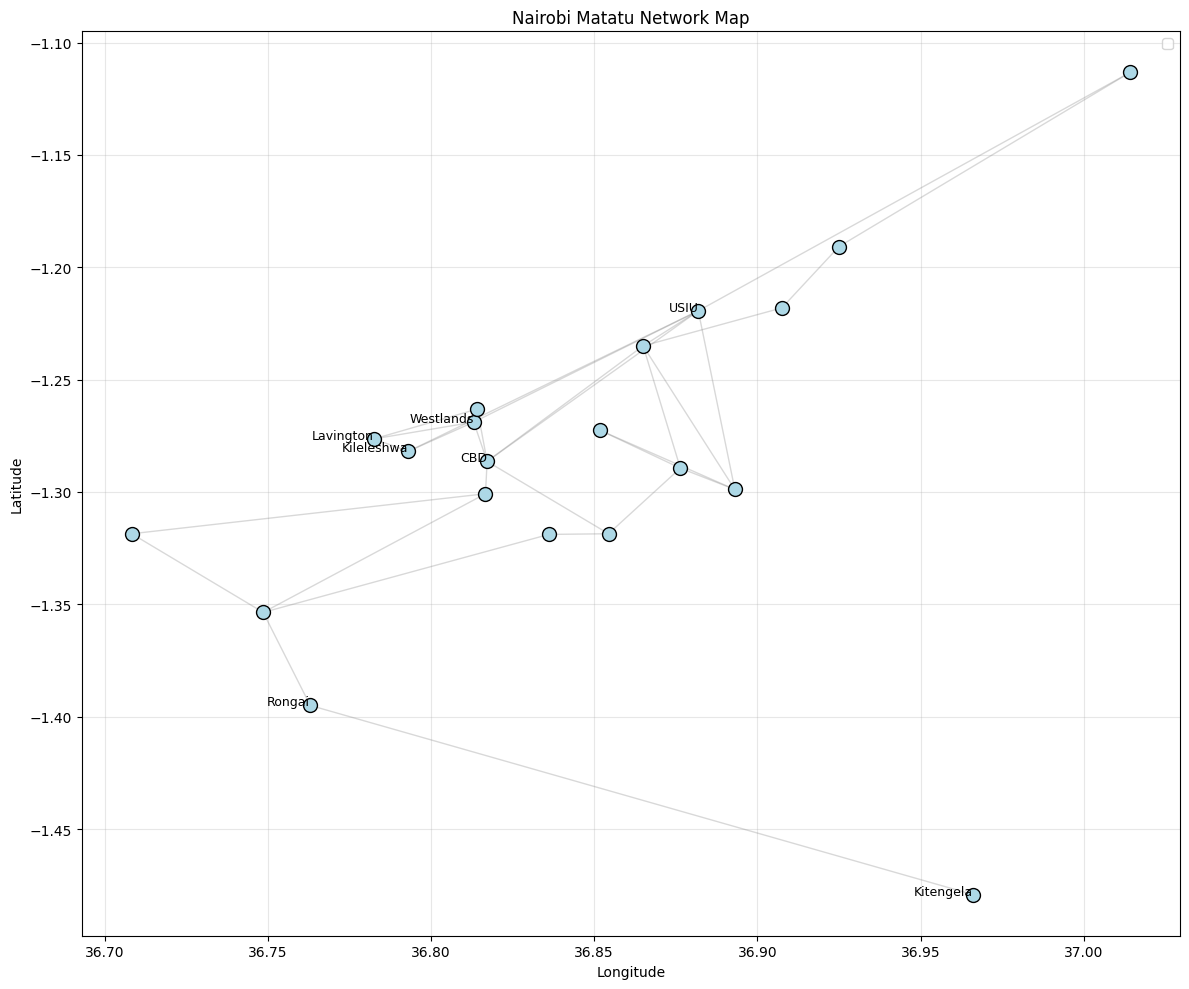

In [ ]:
#visualizing the network
plot_network_colab(graph, title="Nairobi Matatu Network Map")
plt.show()


🔍 FINDING ROUTE: CBD → USIU

📊 ALGORITHM COMPARISON:
+-------------+---------------+--------------+------------------+-----------+
| Algorithm   |   Path Length |   Total Cost |   Nodes Expanded | Runtime   |
+=============+===============+==============+==================+===========+
| BFS         |             2 |           50 |                1 | 0.0000s   |
+-------------+---------------+--------------+------------------+-----------+
| DFS         |             3 |           40 |              255 | 0.0004s   |
+-------------+---------------+--------------+------------------+-----------+
| A* (w=1.0)  |             2 |           40 |                9 | 0.0002s   |
+-------------+---------------+--------------+------------------+-----------+
| A* (w=1.5)  |             2 |           40 |                8 | 0.0001s   |
+-------------+---------------+--------------+------------------+-----------+
| A* (w=0.5)  |             2 |           40 |               11 | 0.0001s   |
+---------

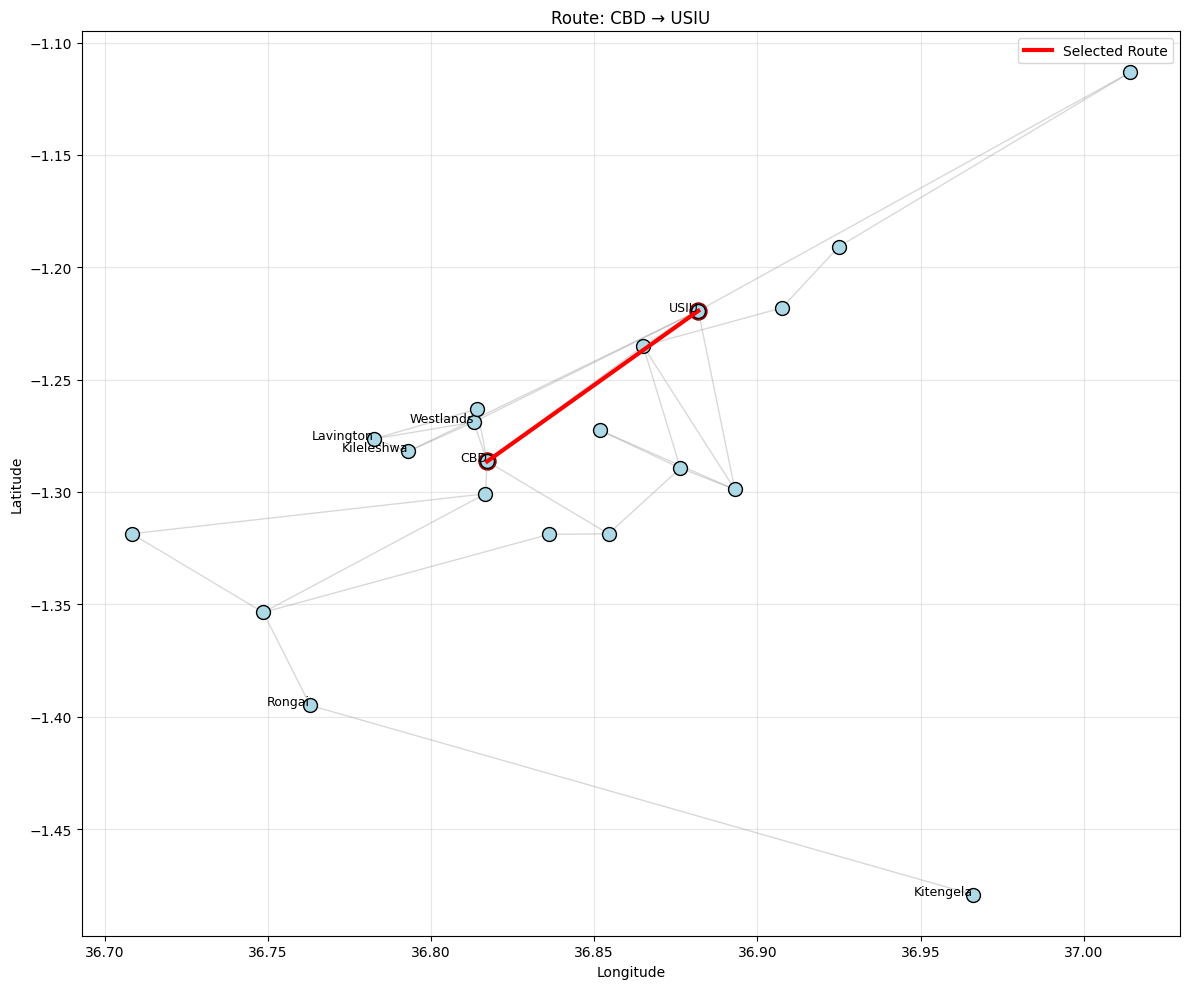

In [ ]:
#route comparison
def find_route(start_name, end_name):
    """Find and compare routes between two stops"""
    #finding node IDs by name
    start_id = None
    end_id = None

    for node_id, data in graph.nodes.items():
        if start_name.lower() in data['name'].lower():
            start_id = node_id
        if end_name.lower() in data['name'].lower():
            end_id = node_id

    if start_id is None or end_id is None:
        print(f"❌ Could not find stops: {start_name} → {end_name}")
        return

    print(f"\n{'='*60}")
    print(f"🔍 FINDING ROUTE: {graph.get_node_name(start_id)} → {graph.get_node_name(end_id)}")
    print(f"{'='*60}")

    #comparing algorithms
    results = compare_algorithms(graph, start_id, end_id, 'time')

    #displaying comparison table
    print("\n📊 ALGORITHM COMPARISON:")
    print(create_comparison_table(results))

    #showing best route (A* standard)
    best = next((r for r in results if r.algorithm == "A* (w=1.0)"), results[0])
    print_route(best, graph)

    #visualizing the route
    plot_network_colab(graph, best.path, title=f"Route: {graph.get_node_name(start_id)} → {graph.get_node_name(end_id)}")
    plt.show()

    return results

#example: finding route from CBD to USIU
results = find_route("CBD", "USIU")


Testing: CBD → USIU
+-------------+---------------+--------------+------------------+-----------+
| Algorithm   |   Path Length |   Total Cost |   Nodes Expanded | Runtime   |
+=============+===============+==============+==================+===========+
| BFS         |             2 |           50 |                1 | 0.0000s   |
+-------------+---------------+--------------+------------------+-----------+
| DFS         |             3 |           40 |              255 | 0.0003s   |
+-------------+---------------+--------------+------------------+-----------+
| A* (w=1.0)  |             2 |           40 |                9 | 0.0001s   |
+-------------+---------------+--------------+------------------+-----------+
| A* (w=1.5)  |             2 |           40 |                8 | 0.0001s   |
+-------------+---------------+--------------+------------------+-----------+
| A* (w=0.5)  |             2 |           40 |               11 | 0.0001s   |
+-------------+---------------+------------

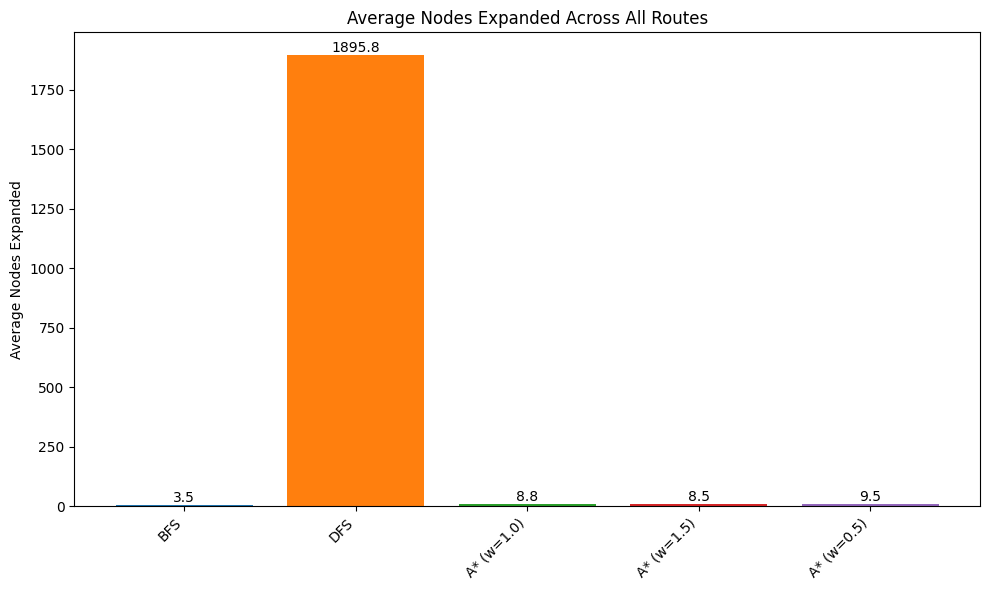

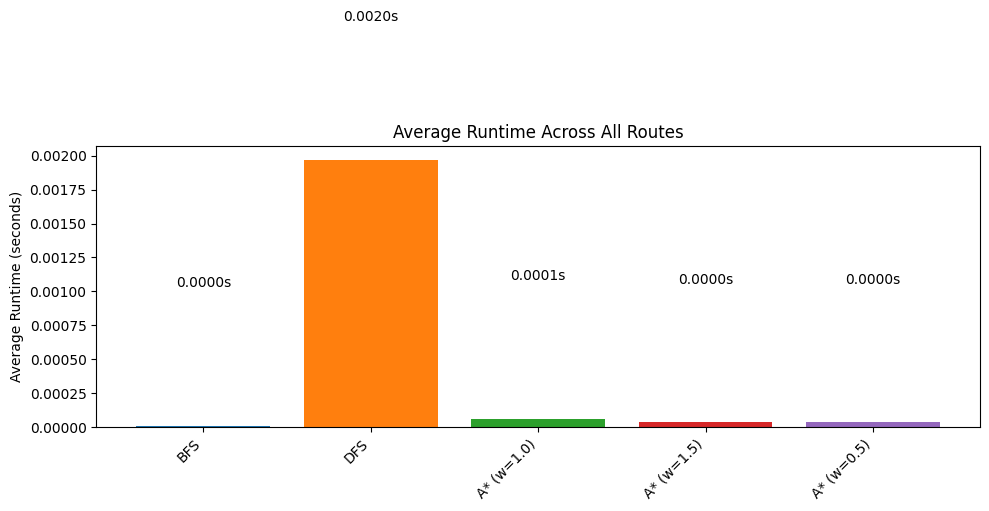

In [ ]:
#comparing algorith performance
test_routes = [
    ("CBD", "USIU"),
    ("Rongai", "Westlands"),
    ("Kitengela", "Karen"),
    ("Juja", "CBD"),
]

all_comparisons = []

for start, end in test_routes:
    print(f"\n{'='*70}")
    print(f"Testing: {start} → {end}")
    print(f"{'='*70}")

    start_id = None
    end_id = None

    for node_id, data in graph.nodes.items():
        if start.lower() in data['name'].lower():
            start_id = node_id
        if end.lower() in data['name'].lower():
            end_id = node_id

    if start_id and end_id:
        results = compare_algorithms(graph, start_id, end_id, 'time')
        print(create_comparison_table(results))
        all_comparisons.append((f"{start}→{end}", results))

#ploting overall performance comparison
print("\n\n📈 OVERALL ALGORITHM PERFORMANCE COMPARISON")
print("="*70)

#average nodes expanded
algorithms = ["BFS", "DFS", "A* (w=1.0)", "A* (w=1.5)", "A* (w=0.5)"]
avg_nodes = {alg: [] for alg in algorithms}
avg_time = {alg: [] for alg in algorithms}

for route_name, results in all_comparisons:
    for r in results:
        if r.algorithm in avg_nodes:
            avg_nodes[r.algorithm].append(r.nodes_expanded)
            avg_time[r.algorithm].append(r.runtime)

#ploting average nodes expanded
plt.figure(figsize=(10, 6))
alg_names = list(avg_nodes.keys())
avg_values = [np.mean(avg_nodes[alg]) for alg in alg_names]
bars = plt.bar(alg_names, avg_values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
plt.ylabel('Average Nodes Expanded')
plt.title('Average Nodes Expanded Across All Routes')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, avg_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

#ploting average runtime
plt.figure(figsize=(10, 6))
avg_time_values = [np.mean(avg_time[alg]) for alg in alg_names]
bars = plt.bar(alg_names, avg_time_values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd'])
plt.ylabel('Average Runtime (seconds)')
plt.title('Average Runtime Across All Routes')
plt.xticks(rotation=45, ha='right')
for bar, val in zip(bars, avg_time_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
             f'{val:.4f}s', ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [ ]:
#interractive route finder
def interactive_finder():
    """Simple interactive route finder for Colab"""
    print("\n" + "="*60)
    print("🚌 INTERACTIVE ROUTE FINDER 🚌")
    print("="*60)

    #showing available stops
    print("\nAvailable stops:")
    for node_id, data in graph.nodes.items():
        print(f"  [{node_id:2d}] {data['name']} ({data['area']})")

    print("\n" + "-"*60)

    while True:
        try:
            print("\nEnter stop numbers or names (type 'quit' to exit)")
            start_input = input("Start stop: ").strip()
            if start_input.lower() == 'quit':
                break

            end_input = input("Destination stop: ").strip()
            if end_input.lower() == 'quit':
                break

            #finding start ID
            start_id = None
            if start_input.isdigit():
                start_id = int(start_input)
            else:
                for node_id, data in graph.nodes.items():
                    if start_input.lower() in data['name'].lower():
                        start_id = node_id
                        break

            #finding end ID
            end_id = None
            if end_input.isdigit():
                end_id = int(end_input)
            else:
                for node_id, data in graph.nodes.items():
                    if end_input.lower() in data['name'].lower():
                        end_id = node_id
                        break

            if start_id is None or end_id is None:
                print("❌ Stop not found. Try again.")
                continue

            #finding route
            results = compare_algorithms(graph, start_id, end_id, 'time')
            print(create_comparison_table(results))

            best = next((r for r in results if r.algorithm == "A* (w=1.0)"), results[0])
            print_route(best, graph)

            #ask for visualization
            viz = input("\nShow visualization? (y/n): ").strip().lower()
            if viz == 'y':
                plot_network_colab(graph, best.path,
                                  title=f"Route: {graph.get_node_name(start_id)} → {graph.get_node_name(end_id)}")
                plt.show()

        except KeyboardInterrupt:
            print("\nGoodbye!")
            break
        except Exception as e:
            print(f"Error: {e}")

In [ ]:
#report results
#comparison table for all test routes
print("\n📊 COMPREHENSIVE ALGORITHM COMPARISON")
print("="*80)

test_scenarios = [
    ("CBD", "USIU", "Urban to Campus"),
    ("Rongai", "Westlands", "Satellite to CBD"),
    ("Kitengela", "Karen", "Peripheral Route"),
    ("Juja", "Eastleigh", "Long Distance"),
]

all_results_data = []

for start, end, desc in test_scenarios:
    start_id = None
    end_id = None

    for node_id, data in graph.nodes.items():
        if start.lower() in data['name'].lower():
            start_id = node_id
        if end.lower() in data['name'].lower():
            end_id = node_id

    if start_id and end_id:
        results = compare_algorithms(graph, start_id, end_id, 'time')

        print(f"\n{desc}: {start} → {end}")
        print("-"*60)

        for r in results:
            path_len = len(r.path) if r.path else 0
            cost = r.cost if r.cost != float('inf') else -1
            print(f"{r.algorithm:15s} | Path: {path_len:2d} stops | Cost: {cost:7.2f} min | Expanded: {r.nodes_expanded:4d} | Time: {r.runtime:.4f}s")
            all_results_data.append({
                'Route': f"{start}→{end}",
                'Description': desc,
                'Algorithm': r.algorithm,
                'Path Length': path_len,
                'Cost (min)': cost,
                'Nodes Expanded': r.nodes_expanded,
                'Runtime (s)': r.runtime
            })

#creating DataFrame
df_results = pd.DataFrame(all_results_data)
print("\n\n📈 SUMMARY STATISTICS")
print("="*80)
summary = df_results.groupby('Algorithm').agg({
    'Cost (min)': 'mean',
    'Nodes Expanded': 'mean',
    'Runtime (s)': 'mean'
}).round(4)
print(summary)


📊 COMPREHENSIVE ALGORITHM COMPARISON

Urban to Campus: CBD → USIU
------------------------------------------------------------
BFS             | Path:  2 stops | Cost:   50.00 min | Expanded:    1 | Time: 0.0000s
DFS             | Path:  3 stops | Cost:   40.00 min | Expanded:  255 | Time: 0.0004s
A* (w=1.0)      | Path:  2 stops | Cost:   40.00 min | Expanded:    9 | Time: 0.0001s
A* (w=1.5)      | Path:  2 stops | Cost:   40.00 min | Expanded:    8 | Time: 0.0001s
A* (w=0.5)      | Path:  2 stops | Cost:   40.00 min | Expanded:   11 | Time: 0.0001s

Satellite to CBD: Rongai → Westlands
------------------------------------------------------------
BFS             | Path:  5 stops | Cost:  100.00 min | Expanded:    7 | Time: 0.0000s
DFS             | Path:  5 stops | Cost:   97.00 min | Expanded: 2090 | Time: 0.0036s
A* (w=1.0)      | Path:  5 stops | Cost:   97.00 min | Expanded:   10 | Time: 0.0001s
A* (w=1.5)      | Path:  5 stops | Cost:   97.00 min | Expanded:   10 | Time: 0.0001s